##  Setup and Imports

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import joblib

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Scikit-learn metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Project imports
from config.config import Config
from src.data_loader import StockDataLoader
from src.evaluator import ModelEvaluator

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" Imports successful")

 Imports successful


##  Load Model and Scalers

In [2]:
# Define paths (update with your model path)
model_dir = project_root / 'models' / 'saved_models'
scaler_dir = project_root / 'models' / 'scalers'

# List available models
model_files = list(model_dir.glob('*.keras'))
print(f"Available models ({len(model_files)}):")
for i, model_file in enumerate(model_files, 1):
    print(f"  {i}. {model_file.name}")

# Load the most recent model (or specify your model)
if model_files:
    model_path = sorted(model_files)[-1]  # Get most recent
    print(f"\nLoading model: {model_path.name}")
    model = keras.models.load_model(model_path)
    print("✓ Model loaded successfully")
else:
    print("⚠ No models found! Please train a model first.")

# Load scalers
feature_scaler_path = scaler_dir / 'feature_scaler.pkl'
target_scaler_path = scaler_dir / 'target_scaler.pkl'

if feature_scaler_path.exists() and target_scaler_path.exists():
    feature_scaler = joblib.load(feature_scaler_path)
    target_scaler = joblib.load(target_scaler_path)
    print("✓ Scalers loaded successfully")
else:
    print("⚠ Scalers not found!")

Available models (2):
  1. lstm_model_20260301_112358.keras
  2. lstm_model_20260301_113127.keras

Loading model: lstm_model_20260301_113127.keras
✓ Model loaded successfully
✓ Scalers loaded successfully


In [3]:
# Display model architecture
print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()


MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,355 (368.58 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,904 (245.72 KB)

## 3. Load and Prepare Test Data

In [4]:
# Load configuration
config = Config()

# Load data
data_path = project_root / config.data.raw_data_path
data_loader = StockDataLoader(str(data_path))
df = data_loader.load_csv(date_column=config.data.date_column)

print(f"✓ Loaded {len(df):,} records")
print(f"✓ Date range: {df[config.data.date_column].min()} to {df[config.data.date_column].max()}")

INFO:src.data_loader:Loaded 245 records from c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv


✓ Loaded 245 records
✓ Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00


In [5]:
# Scale features and target
features = df[config.data.feature_columns].values
target = df[config.data.target_column].values.reshape(-1, 1)

scaled_features = feature_scaler.transform(features)
scaled_target = target_scaler.transform(target)

print(f"✓ Scaled features shape: {scaled_features.shape}")
print(f"✓ Scaled target shape: {scaled_target.shape}")

✓ Scaled features shape: (245, 5)
✓ Scaled target shape: (245, 1)


In [6]:
# Create sequences
def create_sequences(features, target, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(target[i])
    return np.array(X), np.array(y)

sequence_length = config.preprocessing.sequence_length
X, y = create_sequences(scaled_features, scaled_target, sequence_length)

print(f"✓ Created {len(X):,} sequences")
print(f"✓ Sequence shape: {X.shape}")

✓ Created 233 sequences
✓ Sequence shape: (233, 12, 5)


In [7]:
# Split into train, validation, and test sets
train_size = int(len(X) * config.preprocessing.train_ratio)
val_size = int(len(X) * config.preprocessing.validation_ratio)

X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]
X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"\nTest set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")


Test set: 24 samples (10.3%)


## 4. Generate Predictions

In [8]:
# Make predictions on all sets
print("Generating predictions...")

y_train_pred = model.predict(X_train, verbose=0)
y_val_pred = model.predict(X_val, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

print("✓ Predictions generated")

# Inverse transform to original scale
y_train_actual = target_scaler.inverse_transform(y_train)
y_train_pred_actual = target_scaler.inverse_transform(y_train_pred)

y_val_actual = target_scaler.inverse_transform(y_val)
y_val_pred_actual = target_scaler.inverse_transform(y_val_pred)

y_test_actual = target_scaler.inverse_transform(y_test)
y_test_pred_actual = target_scaler.inverse_transform(y_test_pred)

print("✓ Predictions inverse transformed to original scale")

Generating predictions...
✓ Predictions generated
✓ Predictions inverse transformed to original scale


## 5. Calculate Evaluation Metrics

In [9]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate comprehensive evaluation metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    # Additional metrics
    max_error = np.max(np.abs(y_true - y_pred))
    median_ae = np.median(np.abs(y_true - y_pred))
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2,
        'Max Error': max_error,
        'Median AE': median_ae
    }

# Calculate metrics for each set
train_metrics = calculate_metrics(y_train_actual, y_train_pred_actual)
val_metrics = calculate_metrics(y_val_actual, y_val_pred_actual)
test_metrics = calculate_metrics(y_test_actual, y_test_pred_actual)

# Display metrics
print("=" * 80)
print("MODEL EVALUATION METRICS")
print("=" * 80)

metrics_df = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})

print("\n", metrics_df.round(4))

print("\n" + "=" * 80)
print("TEST SET PERFORMANCE")
print("=" * 80)
for metric, value in test_metrics.items():
    if metric in ['MAPE']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")

MODEL EVALUATION METRICS

                 Train  Validation        Test
MSE        67817.3058   8857.1728  20796.7271
RMSE         260.4176     94.1126    144.2107
MAE          170.4892     82.7978    102.9783
MAPE          61.7192     32.4144     27.5259
R2             0.5633     -0.1805      0.0965
Max Error   1317.5045    182.4723    337.5917
Median AE    110.0506     86.1420     58.6233

TEST SET PERFORMANCE
  MSE: 20796.7271
  RMSE: 144.2107
  MAE: 102.9783
  MAPE: 27.53%
  R2: 0.0965
  Max Error: 337.5917
  Median AE: 58.6233


## 6. Visualization: Predictions vs Actual

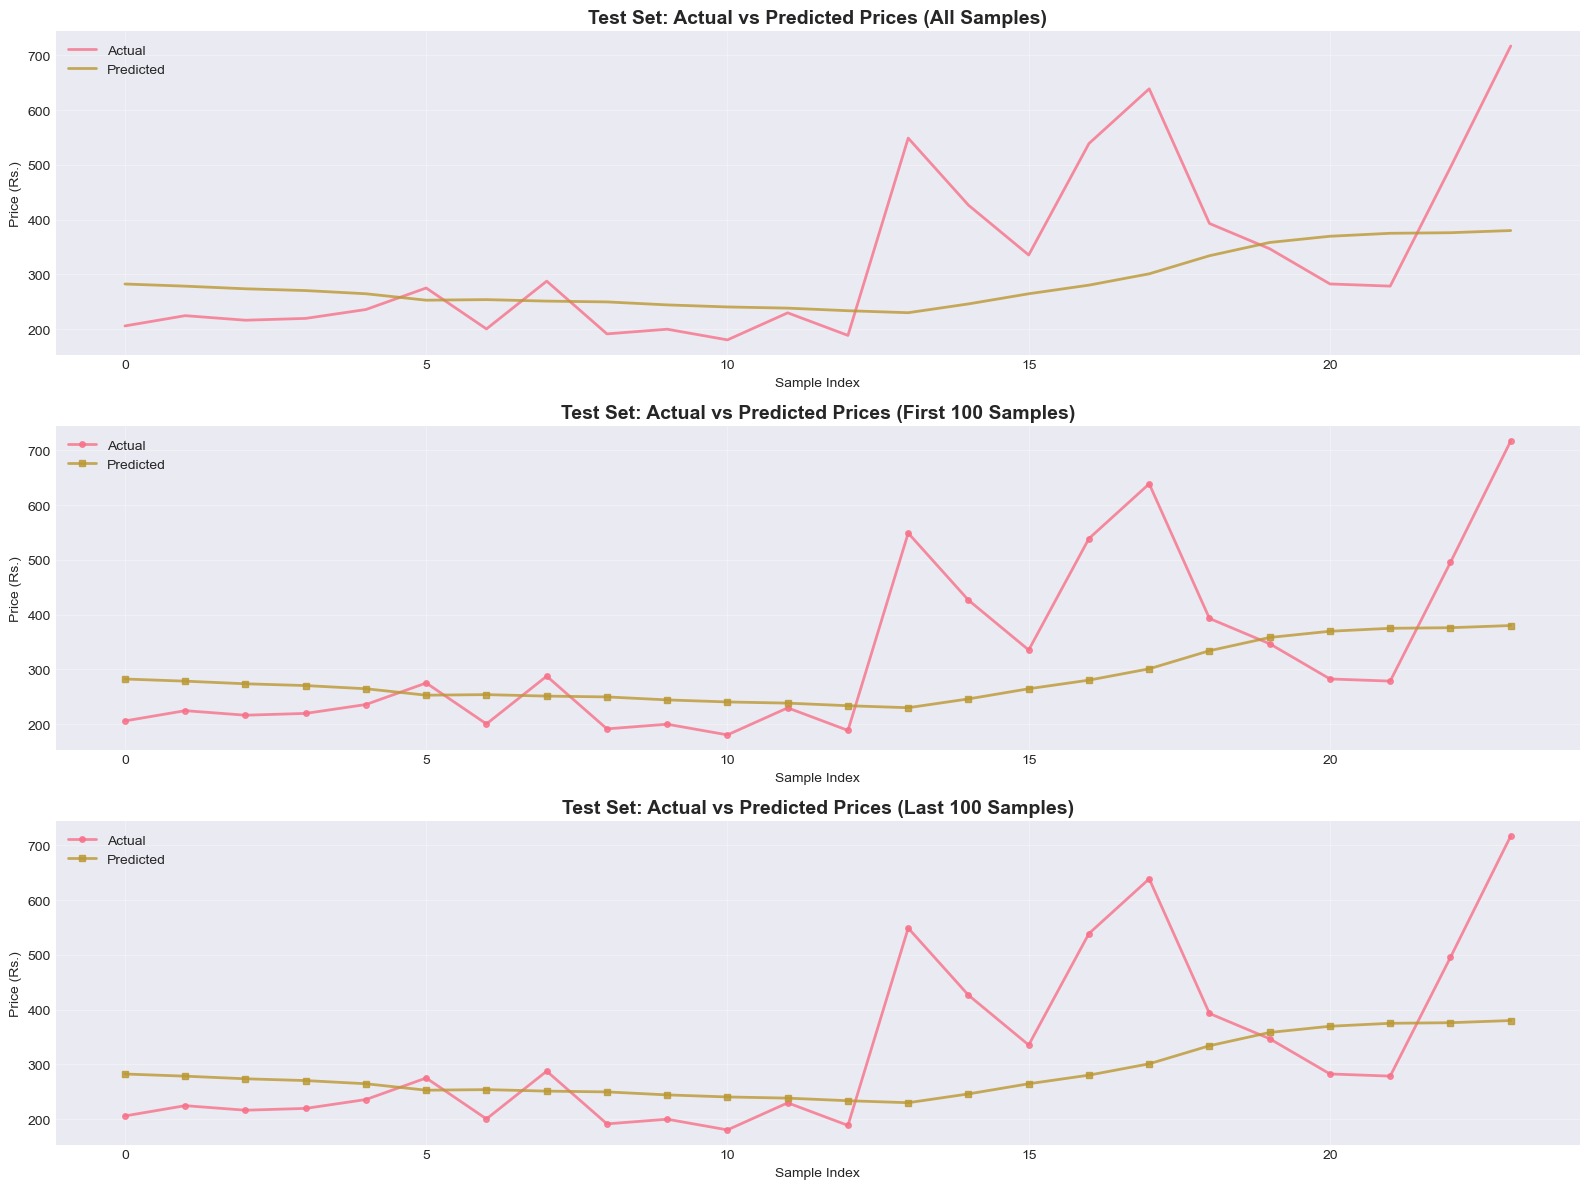

In [10]:
# Plot predictions vs actual for test set
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full test set
axes[0].plot(y_test_actual, label='Actual', linewidth=2, alpha=0.8)
axes[0].plot(y_test_pred_actual, label='Predicted', linewidth=2, alpha=0.8)
axes[0].set_title('Test Set: Actual vs Predicted Prices (All Samples)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Price (Rs.)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First 100 samples
axes[1].plot(y_test_actual[:100], label='Actual', marker='o', markersize=4, linewidth=2, alpha=0.8)
axes[1].plot(y_test_pred_actual[:100], label='Predicted', marker='s', markersize=4, linewidth=2, alpha=0.8)
axes[1].set_title('Test Set: Actual vs Predicted Prices (First 100 Samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Price (Rs.)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Last 100 samples
axes[2].plot(y_test_actual[-100:], label='Actual', marker='o', markersize=4, linewidth=2, alpha=0.8)
axes[2].plot(y_test_pred_actual[-100:], label='Predicted', marker='s', markersize=4, linewidth=2, alpha=0.8)
axes[2].set_title('Test Set: Actual vs Predicted Prices (Last 100 Samples)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Price (Rs.)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Scatter Plot: Predicted vs Actual

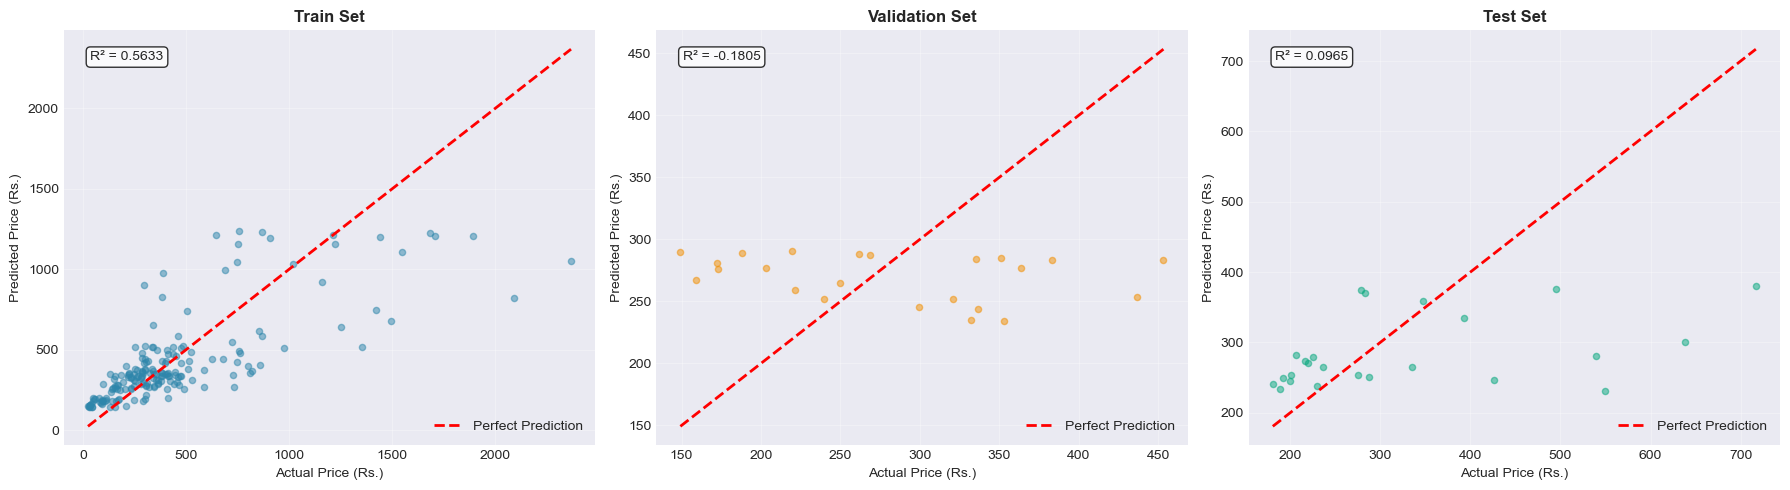

In [11]:
# Scatter plot for all datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('Train', y_train_actual, y_train_pred_actual, '#2E86AB'),
    ('Validation', y_val_actual, y_val_pred_actual, '#F18F01'),
    ('Test', y_test_actual, y_test_pred_actual, '#06A77D')
]

for idx, (name, y_true, y_pred, color) in enumerate(datasets):
    # Scatter plot
    axes[idx].scatter(y_true, y_pred, alpha=0.5, s=20, color=color)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    axes[idx].set_title(f'{name} Set', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Actual Price (Rs.)')
    axes[idx].set_ylabel('Predicted Price (Rs.)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Add R² score
    r2 = r2_score(y_true, y_pred)
    axes[idx].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 8. Error Analysis

In [12]:
# Calculate errors
errors = y_test_actual - y_test_pred_actual
abs_errors = np.abs(errors)
pct_errors = (errors / y_test_actual) * 100

# Error statistics
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)
print(f"\nError Statistics:")
print(f"  Mean Error: {np.mean(errors):.4f}")
print(f"  Std Error: {np.std(errors):.4f}")
print(f"  Min Error: {np.min(errors):.4f}")
print(f"  Max Error: {np.max(errors):.4f}")
print(f"  Median Absolute Error: {np.median(abs_errors):.4f}")
print(f"  95th Percentile Error: {np.percentile(abs_errors, 95):.4f}")

ERROR ANALYSIS

Error Statistics:
  Mean Error: 41.9629
  Std Error: 137.9704
  Min Error: -96.3966
  Max Error: 337.5917
  Median Absolute Error: 58.6233
  95th Percentile Error: 334.0286


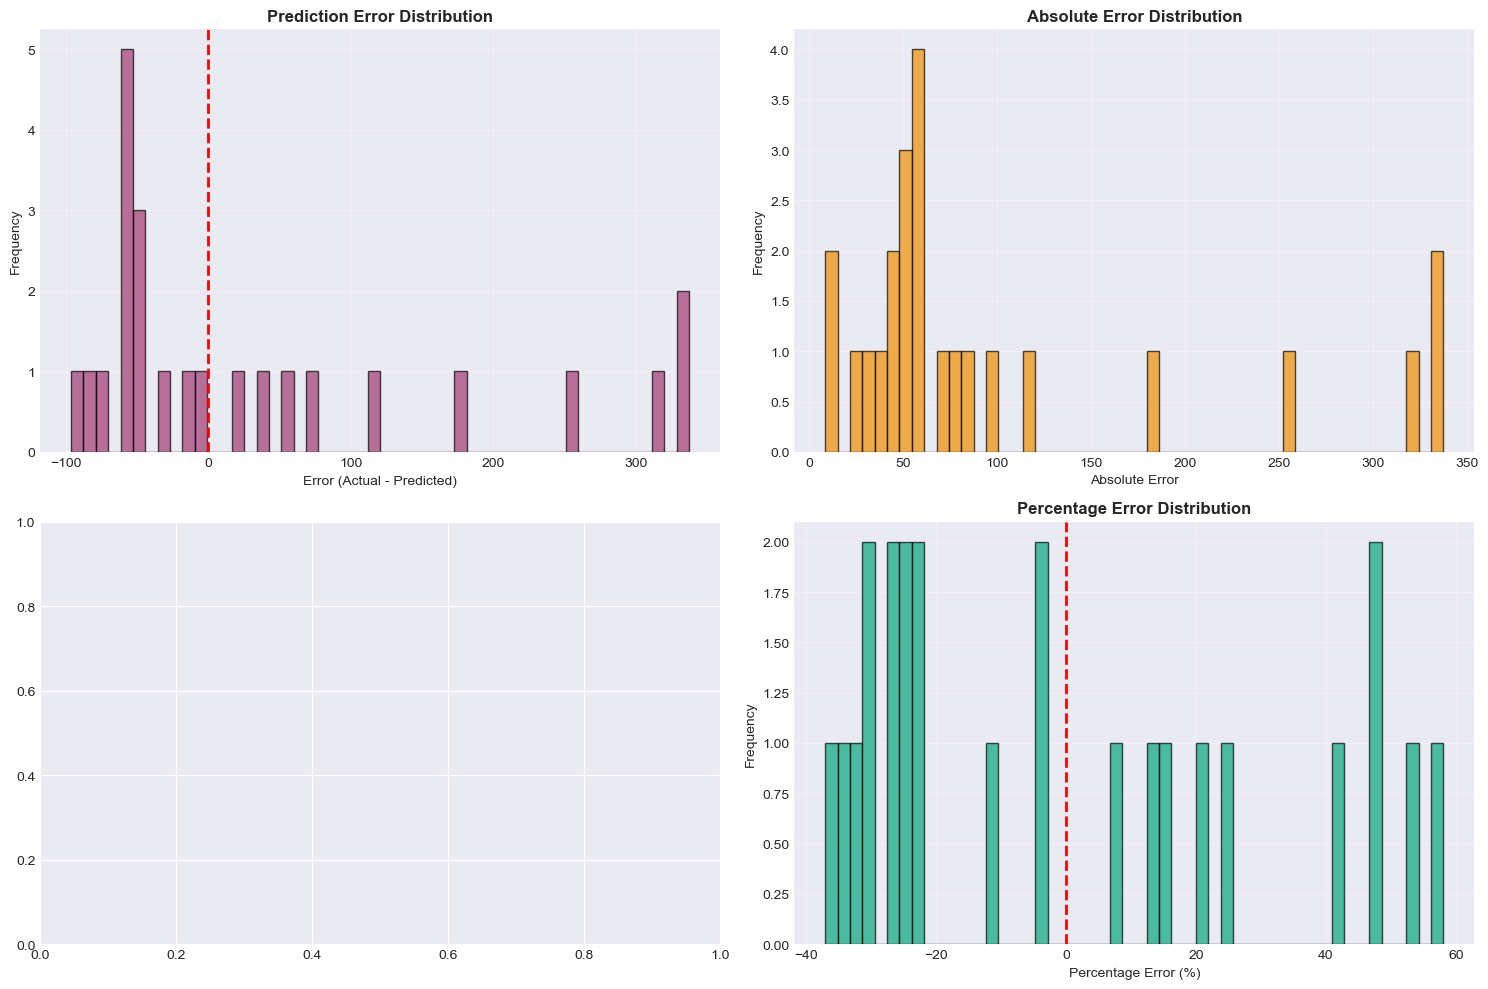

In [14]:
# Error distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Error histogram
axes[0, 0].hist(errors, bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Error (Actual - Predicted)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Absolute error histogram
axes[0, 1].hist(abs_errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Absolute Error Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Absolute Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# # Error over time
# axes[1, 0].plot(errors, linewidth=1, color='#2E86AB', alpha=0.7)
# axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
# axes[1, 0].fill_between(range(len(errors)), errors, 0, alpha=0.3,
#                        where=(errors > 0), facecolor='green', label='Overestimation')
# axes[1, 0].fill_between(range(len(errors)), errors, 0, alpha=0.3,
#                        where=(errors < 0), facecolor='red', label='Underestimation')
# axes[1, 0].set_title('Prediction Errors Over Time', fontsize=12, fontweight='bold')
# axes[1, 0].set_xlabel('Sample Index')
# axes[1, 0].set_ylabel('Error')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# Percentage error distribution
axes[1, 1].hist(pct_errors, bins=50, color='#06A77D', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Percentage Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Residual Analysis

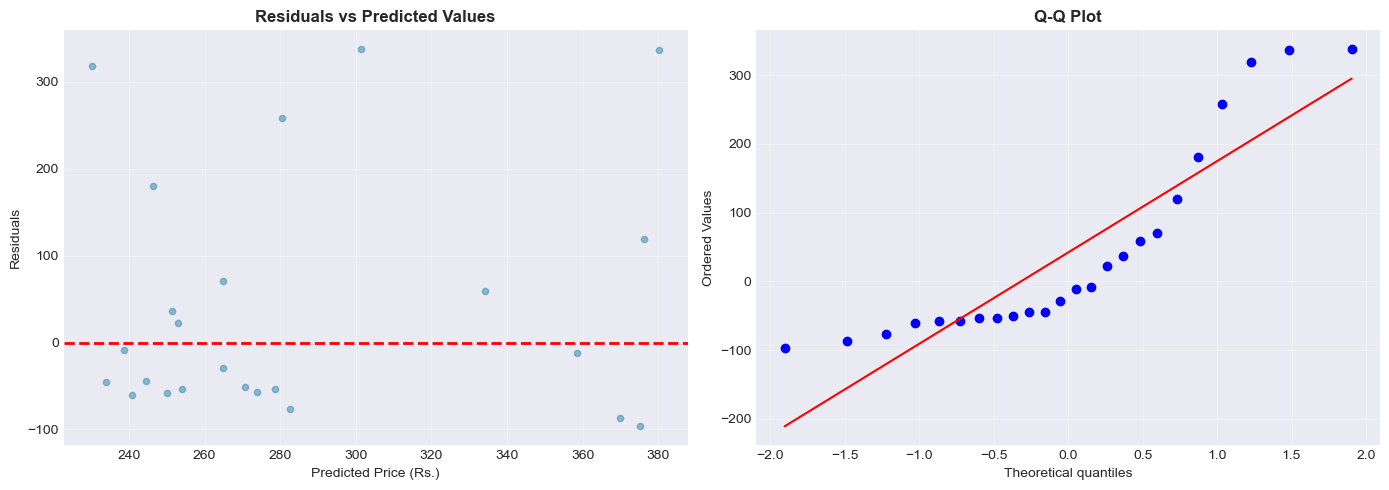

In [15]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_test_pred_actual, errors, alpha=0.5, s=20, color='#2E86AB')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Price (Rs.)')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(errors.flatten(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Performance by Price Range

In [16]:
# Analyze performance by price range
price_ranges = [
    (0, np.percentile(y_test_actual, 25)),
    (np.percentile(y_test_actual, 25), np.percentile(y_test_actual, 50)),
    (np.percentile(y_test_actual, 50), np.percentile(y_test_actual, 75)),
    (np.percentile(y_test_actual, 75), np.max(y_test_actual))
]

range_names = ['Q1 (Low)', 'Q2 (Med-Low)', 'Q3 (Med-High)', 'Q4 (High)']

print("\n" + "=" * 60)
print("PERFORMANCE BY PRICE RANGE")
print("=" * 60)

range_metrics = []
for (low, high), name in zip(price_ranges, range_names):
    mask = (y_test_actual >= low) & (y_test_actual <= high)
    if mask.sum() > 0:
        y_true_range = y_test_actual[mask]
        y_pred_range = y_test_pred_actual[mask]
        
        mae = mean_absolute_error(y_true_range, y_pred_range)
        mape = np.mean(np.abs((y_true_range - y_pred_range) / y_true_range)) * 100
        r2 = r2_score(y_true_range, y_pred_range)
        
        range_metrics.append({
            'Range': name,
            'Price Range': f'{low:.2f} - {high:.2f}',
            'Samples': mask.sum(),
            'MAE': mae,
            'MAPE': mape,
            'R²': r2
        })

range_df = pd.DataFrame(range_metrics)
print("\n", range_df.to_string(index=False))


PERFORMANCE BY PRICE RANGE

         Range     Price Range  Samples        MAE      MAPE         R²
     Q1 (Low)   0.00 - 213.95        6  56.321429 28.927294 -44.102055
 Q2 (Med-Low) 213.95 - 277.07        6  36.929862 16.253749  -3.385607
Q3 (Med-High) 277.07 - 401.48        6  60.163374 19.564642  -1.569235
    Q4 (High) 401.48 - 716.95        6 258.498586 45.357935  -7.290030


## 11. Save Evaluation Results

In [17]:
# Create results directory
results_dir = project_root / 'results' / f'evaluation_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
results_dir.mkdir(parents=True, exist_ok=True)

# Save metrics
metrics_df.to_csv(results_dir / 'metrics.csv')
range_df.to_csv(results_dir / 'metrics_by_range.csv', index=False)

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test_actual.flatten(),
    'Predicted': y_test_pred_actual.flatten(),
    'Error': errors.flatten(),
    'Absolute_Error': abs_errors.flatten(),
    'Percentage_Error': pct_errors.flatten()
})
predictions_df.to_csv(results_dir / 'test_predictions.csv', index=False)

print(f"✓ Evaluation results saved to: {results_dir}")
print(f"  - Metrics: metrics.csv")
print(f"  - Range metrics: metrics_by_range.csv")
print(f"  - Predictions: test_predictions.csv")

✓ Evaluation results saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\results\evaluation_20260301_120106
  - Metrics: metrics.csv
  - Range metrics: metrics_by_range.csv
  - Predictions: test_predictions.csv


## 12. Evaluation Summary

In [19]:
# Final summary

print("EVALUATION SUMMARY")


print(f"\n Model: {model_path.name}")
print(f" Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n Test Set Performance:")
print(f"  - RMSE: {test_metrics['RMSE']:.4f} Rs.")
print(f"  - MAE: {test_metrics['MAE']:.4f} Rs.")
print(f"  - MAPE: {test_metrics['MAPE']:.2f}%")
print(f"  - R² Score: {test_metrics['R2']:.4f}")

print(f"\n Dataset Sizes:")
print(f"  - Training: {len(y_train):,} samples")
print(f"  - Validation: {len(y_val):,} samples")
print(f"  - Test: {len(y_test):,} samples")

print(f"\n Results saved to: {results_dir}")

# Model quality assessment
if test_metrics['MAPE'] < 5:
    quality = "Excellent"
elif test_metrics['MAPE'] < 10:
    quality = "Good"
elif test_metrics['MAPE'] < 20:
    quality = "Fair"
else:
    quality = "Needs Improvement"

print(f"\n Model Quality: {quality} (based on MAPE)")
print("\n✓ Model evaluation completed successfully!")

EVALUATION SUMMARY

 Model: lstm_model_20260301_113127.keras
 Evaluation Date: 2026-03-01 12:01:54

 Test Set Performance:
  - RMSE: 144.2107 Rs.
  - MAE: 102.9783 Rs.
  - MAPE: 27.53%
  - R² Score: 0.0965

 Dataset Sizes:
  - Training: 186 samples
  - Validation: 23 samples
  - Test: 24 samples

 Results saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\results\evaluation_20260301_120106

 Model Quality: Needs Improvement (based on MAPE)

✓ Model evaluation completed successfully!
